# TA3 - Fine-Tuning a Hugging Face Foundation Model on FashionMNIST (Manual PyTorch, No Lightning)

This notebook implements the full training loop manually (no PyTorch Lightning), including deterministic split, train-only normalization statistics, checkpointing (`best.pt` + `last.pt`), resume support, and final persistence/export.

## Imports and Setup

In [2]:
import json
import os
import random
import time
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode
from torchinfo import summary

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from transformers import AutoImageProcessor, AutoModelForImageClassification

import onnx
import onnxruntime as ort

from plot_utils import plot_random_raw_samples, plot_one_per_class

In [3]:
SEED = 2711775712


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

if torch.backends.mps.is_built() and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Using device: {DEVICE}')

Using device: mps


In [4]:
DATA_ROOT = Path('../data')
ARTIFACT_DIR = Path('./artifacts_ta3_ft_test')
CKPT_DIR = ARTIFACT_DIR / 'checkpoints'
FINAL_HF_DIR = ARTIFACT_DIR / 'final_hf'
ONNX_DIR = ARTIFACT_DIR / 'onnx'

for p in [ARTIFACT_DIR, CKPT_DIR, FINAL_HF_DIR, ONNX_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CHECKPOINT_BEST_PATH = CKPT_DIR / 'best.pt'
CHECKPOINT_LAST_PATH = CKPT_DIR / 'last.pt'

MODEL_NAME = 'google/vit-base-patch16-224-in21k'
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
NUM_CLASSES = len(CLASS_NAMES)

VAL_RATIO = 0.10
BATCH_SIZE = 32
MAX_EPOCHS = 8
EARLY_STOPPING_PATIENCE = 3
LR = 2e-4
WEIGHT_DECAY = 1e-4

NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = torch.cuda.is_available()
AMP_ENABLED = (DEVICE.type == 'cuda')

print(f'Model: {MODEL_NAME}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Epochs: {MAX_EPOCHS}')
print(f'Artifacts dir: {ARTIFACT_DIR.resolve()}')
print(f'AMP enabled: {AMP_ENABLED}')

Model: google/vit-base-patch16-224-in21k
Batch size: 32
Epochs: 8
Artifacts dir: /Users/guillem/Documents/DL_TA_Sessions/session_3/artifacts_ta3_ft_test
AMP enabled: False


## Checkpoint Strategy (Raw PyTorch)

We use **full `.pt` checkpoints** and keep only:
- `best.pt`: highest validation multiclass accuracy so far
- `last.pt`: latest epoch (for robust resume)

This is the best tradeoff for teaching manual training + safe resume while minimizing disk usage.

### Other common options
- `model.state_dict()` only: smaller, but no optimizer/scheduler/scaler/RNG resume.
- `save_pretrained()` only: good for inference sharing, weak for exact training resume.

## Data Loading and Raw Data Exploration

In [5]:
raw_train = datasets.FashionMNIST(root=DATA_ROOT, train=True, download=True, transform=None)
raw_test = datasets.FashionMNIST(root=DATA_ROOT, train=False, download=True, transform=None)

print(f'Train size: {len(raw_train):,}')
print(f'Test size: {len(raw_test):,}')
print(f'Raw image size: {raw_train[0][0].size} (grayscale)')
print(f'Classes in dataset: {len(raw_train.classes)}')

Train size: 60,000
Test size: 10,000
Raw image size: (28, 28) (grayscale)
Classes in dataset: 10


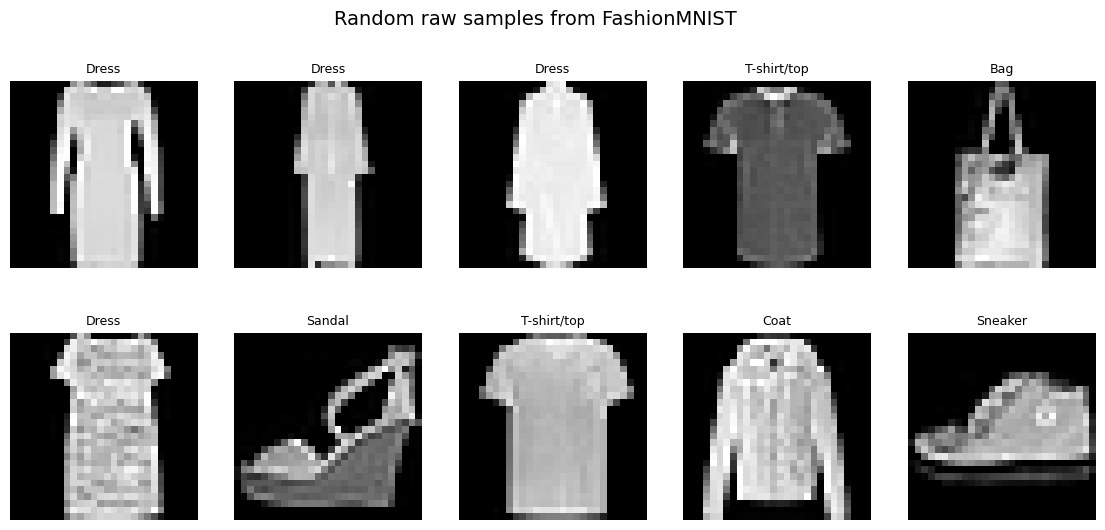

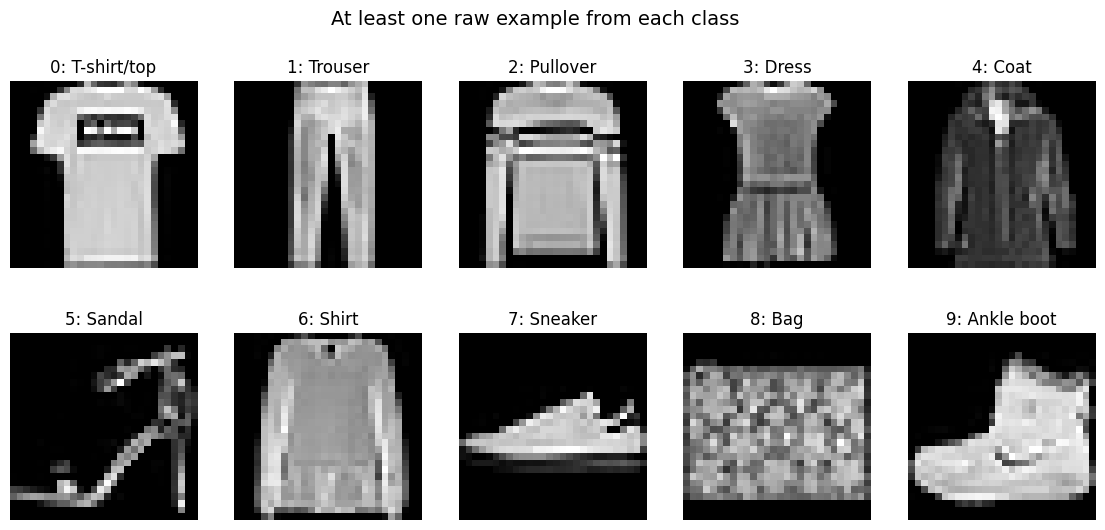

In [6]:
plot_random_raw_samples(raw_train, CLASS_NAMES, n=10, seed=SEED)
plot_one_per_class(raw_train, CLASS_NAMES)

## Deterministic Train/Validation Split and Purist Normalization Stats

Important: mean/std are computed **only from the train split** (not val/test), using the exact deterministic split indices.

In [7]:
train_targets = raw_train.targets.numpy()
all_indices = np.arange(len(train_targets))

train_idx, val_idx = train_test_split(
    all_indices,
    test_size=VAL_RATIO,
    random_state=SEED,
    stratify=train_targets,
    shuffle=True,
)

print(f'Train subset size: {len(train_idx):,}')
print(f'Validation subset size: {len(val_idx):,}')

Train subset size: 54,000
Validation subset size: 6,000


In [8]:
train_pixels = raw_train.data[train_idx].float() / 255.0
train_mean_scalar = float(train_pixels.mean().item())
train_std_scalar = float(train_pixels.std(unbiased=False).item())

# FashionMNIST is grayscale; after channel replication to RGB we use the same stats per channel.
IMAGE_MEAN = [train_mean_scalar] * 3
IMAGE_STD = [max(train_std_scalar, 1e-8)] * 3

print(f'Train-only mean (grayscale): {train_mean_scalar:.6f}')
print(f'Train-only std  (grayscale): {train_std_scalar:.6f}')
print(f'Applied RGB mean: {IMAGE_MEAN}')
print(f'Applied RGB std: {IMAGE_STD}')

Train-only mean (grayscale): 0.285947
Train-only std  (grayscale): 0.353023
Applied RGB mean: [0.2859467566013336, 0.2859467566013336, 0.2859467566013336]
Applied RGB std: [0.35302332043647766, 0.35302332043647766, 0.35302332043647766]


## Processor, Transforms, and DataLoaders

We keep ViT-Base-224 and adapt FashionMNIST from `1x28x28` to `3x224x224`.

In [9]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

if isinstance(processor.size, dict):
    if 'height' in processor.size and 'width' in processor.size:
        IMG_HEIGHT = int(processor.size['height'])
        IMG_WIDTH = int(processor.size['width'])
    elif 'shortest_edge' in processor.size:
        IMG_HEIGHT = IMG_WIDTH = int(processor.size['shortest_edge'])
    else:
        IMG_HEIGHT = IMG_WIDTH = 224
else:
    IMG_HEIGHT = IMG_WIDTH = int(processor.size)

print(f'Processor size field: {processor.size}')
print(f'Model input size used: {(IMG_HEIGHT, IMG_WIDTH)}')
print(f'Processor mean/std (reference): {processor.image_mean} / {processor.image_std}')
print(f'Dataset train-only mean/std (used): {IMAGE_MEAN} / {IMAGE_STD}')

train_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH), interpolation=InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGE_MEAN, std=IMAGE_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH), interpolation=InterpolationMode.BICUBIC),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGE_MEAN, std=IMAGE_STD),
])

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Processor size field: {'height': 224, 'width': 224}
Model input size used: (224, 224)
Processor mean/std (reference): [0.5, 0.5, 0.5] / [0.5, 0.5, 0.5]
Dataset train-only mean/std (used): [0.2859467566013336, 0.2859467566013336, 0.2859467566013336] / [0.35302332043647766, 0.35302332043647766, 0.35302332043647766]


In [10]:
train_dataset = datasets.FashionMNIST(root=DATA_ROOT, train=True, download=False, transform=train_transform)
val_dataset = datasets.FashionMNIST(root=DATA_ROOT, train=True, download=False, transform=eval_transform)
test_dataset = datasets.FashionMNIST(root=DATA_ROOT, train=False, download=False, transform=eval_transform)

train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(val_dataset, val_idx)

def make_dataloader(ds, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(NUM_WORKERS > 0),
    )

train_loader = make_dataloader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_dataloader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = make_dataloader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

x_example, y_example = next(iter(train_loader))
print('Batch X shape:', tuple(x_example.shape))
print('Batch y shape:', tuple(y_example.shape))
print('Label min/max:', int(y_example.min()), int(y_example.max()))

Batch X shape: (32, 3, 224, 224)
Batch y shape: (32,)
Label min/max: 0 9


## Load Model Once (Outside Training Function) + Summary

Model is loaded exactly once and reused throughout the notebook.

In [ ]:
id2label = {idx: name for idx, name in enumerate(CLASS_NAMES)}
label2id = {name: idx for idx, name in enumerate(CLASS_NAMES)}

model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model = model.to(DEVICE)
model.train()

print('Model loaded once and moved to device.')
print(summary(
    model,
    input_size=(1, 3, IMG_HEIGHT, IMG_WIDTH),
    device=str(DEVICE),
    depth=2,
))

# Keep explicit train mode after summary.
model.train()

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

## Manual Training and Checkpoint Utilities

In [ ]:
def compute_epoch_metrics(y_true: list[int], y_pred: list[int]) -> dict[str, float]:
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
    }


def get_rng_state() -> dict[str, Any]:
    state: dict[str, Any] = {
        'python': random.getstate(),
        'numpy': np.random.get_state(),
        'torch_cpu': torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state['torch_cuda'] = torch.cuda.get_rng_state_all()
    return state


def set_rng_state(state: dict[str, Any]) -> None:
    random.setstate(state['python'])
    np.random.set_state(state['numpy'])
    torch.set_rng_state(state['torch_cpu'])
    if torch.cuda.is_available() and 'torch_cuda' in state:
        torch.cuda.set_rng_state_all(state['torch_cuda'])


def save_checkpoint(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(payload, path)


def load_checkpoint(path: Path, device: torch.device) -> dict[str, Any]:
    return torch.load(path, map_location=device, weights_only=False)


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    scaler: torch.amp.GradScaler,
) -> dict[str, float]:
    model.train()
    losses = []
    all_true, all_pred = [], []

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if AMP_ENABLED:
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(pixel_values=x)
                logits = outputs.logits
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(pixel_values=x)
            logits = outputs.logits
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        losses.append(loss.item())
        all_true.extend(y.detach().cpu().tolist())
        all_pred.extend(torch.argmax(logits.detach(), dim=1).cpu().tolist())

    metrics = compute_epoch_metrics(all_true, all_pred)
    metrics['loss'] = float(np.mean(losses))
    return metrics


@torch.no_grad()
def evaluate_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
) -> tuple[dict[str, float], list[int], list[int]]:
    model.eval()
    losses = []
    all_true, all_pred = [], []

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        if AMP_ENABLED:
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(pixel_values=x)
                logits = outputs.logits
                loss = criterion(logits, y)
        else:
            outputs = model(pixel_values=x)
            logits = outputs.logits
            loss = criterion(logits, y)

        losses.append(loss.item())
        all_true.extend(y.detach().cpu().tolist())
        all_pred.extend(torch.argmax(logits.detach(), dim=1).cpu().tolist())

    metrics = compute_epoch_metrics(all_true, all_pred)
    metrics['loss'] = float(np.mean(losses))
    return metrics, all_true, all_pred


def run_training(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.LRScheduler,
    criterion: nn.Module,
    scaler: torch.amp.GradScaler,
    max_epochs: int,
    early_stopping_patience: int,
    best_ckpt_path: Path,
    last_ckpt_path: Path,
    resume: bool = True,
) -> dict[str, Any]:
    start_epoch = 0
    best_val_accuracy = -1.0
    epochs_without_improvement = 0
    history_rows: list[dict[str, float]] = []

    if resume and last_ckpt_path.exists():
        payload = load_checkpoint(last_ckpt_path, DEVICE)
        model.load_state_dict(payload['model_state_dict'])
        optimizer.load_state_dict(payload['optimizer_state_dict'])
        scheduler.load_state_dict(payload['scheduler_state_dict'])
        if payload.get('scaler_state_dict') is not None:
            scaler.load_state_dict(payload['scaler_state_dict'])

        start_epoch = int(payload['epoch']) + 1
        best_val_accuracy = float(payload['best_val_accuracy'])
        epochs_without_improvement = int(payload['epochs_without_improvement'])
        history_rows = payload.get('history_rows', [])

        if payload.get('rng_state') is not None:
            set_rng_state(payload['rng_state'])

        print(f"Resuming from epoch {start_epoch} with best_val_accuracy={best_val_accuracy:.4f}")

    for epoch in range(start_epoch, max_epochs):
        epoch_start = time.perf_counter()

        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_metrics, _, _ = evaluate_one_epoch(model, val_loader, criterion)

        scheduler.step()

        epoch_row = {
            'epoch': epoch,
            'lr': optimizer.param_groups[0]['lr'],
            'train_loss': train_metrics['loss'],
            'train_acc': train_metrics['accuracy'],
            'train_macro_f1': train_metrics['macro_f1'],
            'val_loss': val_metrics['loss'],
            'val_acc': val_metrics['accuracy'],
            'val_macro_f1': val_metrics['macro_f1'],
        }
        history_rows.append(epoch_row)

        improved = val_metrics['accuracy'] > best_val_accuracy
        if improved:
            best_val_accuracy = val_metrics['accuracy']
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        checkpoint_payload = {
            'epoch': epoch,
            'best_val_accuracy': best_val_accuracy,
            'epochs_without_improvement': epochs_without_improvement,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'scaler_state_dict': scaler.state_dict() if AMP_ENABLED else None,
            'history_rows': history_rows,
            'rng_state': get_rng_state(),
            'config': {
                'model_name': MODEL_NAME,
                'batch_size': BATCH_SIZE,
                'max_epochs': max_epochs,
                'lr': LR,
                'weight_decay': WEIGHT_DECAY,
                'early_stopping_patience': early_stopping_patience,
                'val_ratio': VAL_RATIO,
                'seed': SEED,
            },
        }

        # Always keep only the latest checkpoint for resume.
        save_checkpoint(last_ckpt_path, checkpoint_payload)

        # Keep only one best checkpoint file (overwrite when improved).
        if improved:
            save_checkpoint(best_ckpt_path, checkpoint_payload)

        epoch_minutes = (time.perf_counter() - epoch_start) / 60.0
        print(
            f"Epoch {epoch + 1:03d}/{max_epochs:03d} | "
            f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['accuracy']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['accuracy']:.4f} "
            f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
            f"best_val_acc={best_val_accuracy:.4f} | "
            f"{epoch_minutes:.2f} min"
        )

        if epochs_without_improvement >= early_stopping_patience:
            print(f'Early stopping triggered (patience={early_stopping_patience}).')
            break

    history_df = pd.DataFrame(history_rows)
    return {
        'history_df': history_df,
        'best_val_accuracy': float(best_val_accuracy),
        'epochs_ran': int(len(history_rows)),
        'best_checkpoint_path': str(best_ckpt_path),
        'last_checkpoint_path': str(last_ckpt_path),
    }

## Train (Manual Loop)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)

start_time = time.perf_counter()
train_result = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    scaler=scaler,
    max_epochs=MAX_EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    best_ckpt_path=CHECKPOINT_BEST_PATH,
    last_ckpt_path=CHECKPOINT_LAST_PATH,
    resume=True,
)
training_minutes = (time.perf_counter() - start_time) / 60.0

print(f"
Training finished in {training_minutes:.2f} minutes")
print('Best validation accuracy:', round(train_result['best_val_accuracy'], 4))
print('Epochs executed:', train_result['epochs_ran'])
print('Best checkpoint:', train_result['best_checkpoint_path'])
print('Last checkpoint:', train_result['last_checkpoint_path'])

train_result['history_df'].tail()

## Evaluate Best Checkpoint on Test Data

In [ ]:
best_payload = load_checkpoint(CHECKPOINT_BEST_PATH, DEVICE)
model.load_state_dict(best_payload['model_state_dict'])
model = model.to(DEVICE)

criterion_eval = nn.CrossEntropyLoss()
test_metrics, y_true_test, y_pred_test = evaluate_one_epoch(model, test_loader, criterion_eval)

print('Test metrics (out-of-sample):')
print(f"  Loss:      {test_metrics['loss']:.4f}")
print(f"  Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"  Macro-F1:  {test_metrics['macro_f1']:.4f}")

print('
Per-class report:')
print(classification_report(y_true_test, y_pred_test, target_names=CLASS_NAMES, digits=4))

In [ ]:
cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.title('Test confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

## Save Final Hugging Face Artifacts

In [ ]:
model.save_pretrained(FINAL_HF_DIR)
processor.save_pretrained(FINAL_HF_DIR)
(FINAL_HF_DIR / 'class_names.json').write_text(json.dumps(CLASS_NAMES, indent=2))

print(f'Saved Hugging Face model + processor to: {FINAL_HF_DIR.resolve()}')

## Optional ONNX Export (from Best Weights)

In [ ]:
class HFLogitsWrapper(nn.Module):
    def __init__(self, hf_model: nn.Module):
        super().__init__()
        self.hf_model = hf_model

    def forward(self, pixel_values: torch.Tensor) -> torch.Tensor:
        return self.hf_model(pixel_values=pixel_values).logits


onnx_path = ONNX_DIR / 'fashionmnist_vit_best.onnx'
export_wrapper = HFLogitsWrapper(model).cpu().eval()
dummy_input = torch.randn(1, 3, IMG_HEIGHT, IMG_WIDTH, dtype=torch.float32)

torch.onnx.export(
    export_wrapper,
    dummy_input,
    str(onnx_path),
    input_names=['pixel_values'],
    output_names=['logits'],
    dynamic_axes={
        'pixel_values': {0: 'batch_size'},
        'logits': {0: 'batch_size'},
    },
    opset_version=17,
    do_constant_folding=True,
    dynamo=False,
)

onnx_model = onnx.load(str(onnx_path))
onnx.checker.check_model(onnx_model)

print(f'ONNX model exported and validated at: {onnx_path.resolve()}')

In [ ]:
ort_session = ort.InferenceSession(str(onnx_path), providers=['CPUExecutionProvider'])

x_batch, _ = next(iter(test_loader))
x_sample = x_batch[:16].cpu()

with torch.no_grad():
    torch_logits = export_wrapper(x_sample).numpy()

ort_logits = ort_session.run(['logits'], {'pixel_values': x_sample.numpy()})[0]

torch_pred = torch_logits.argmax(axis=1)
ort_pred = ort_logits.argmax(axis=1)
agreement = (torch_pred == ort_pred).mean()

print(f'PyTorch logits shape: {torch_logits.shape}')
print(f'ONNX logits shape: {ort_logits.shape}')
print(f'Top-1 agreement on sample batch: {agreement:.4f}')

## Resume Training Notes

This notebook resumes automatically from `last.pt` if it exists.

- Keep both `best.pt` and `last.pt` for robustness.
- Delete `last.pt` if you want to force a fresh training run from scratch.